### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor

In [4]:
from xgboost import XGBRegressor
from imblearn.over_sampling import RandomOverSampler
from feature_engine.selection import SmartCorrelatedSelection

### Step 2: Load Data

In [15]:
df1 = pd.read_csv('./data/calories.csv')
df2 = pd.read_csv('./data/exercise.csv')
df = pd.merge(df1, df2, on='User_ID')

In [16]:
df.shape

(15000, 9)

In [17]:
df.head()

,User_ID,Calories,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,231.0,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,66.0,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,26.0,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,71.0,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,35.0,female,27,154.0,58.0,10.0,81.0,39.8


### Step 3: Exploaring Data

#### Basic Info

In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
User_ID,15000.0,1.497736e+07,2.872851e+06,10001159.0,12474190.75,14997285.0,17449278.75,19999647.0
Calories,15000.0,8.953953e+01,6.245698e+01,1.0,35.00,79.0,138.00,314.0
Age,15000.0,4.278980e+01,1.698026e+01,20.0,28.00,39.0,56.00,79.0
Height,15000.0,1.744651e+02,1.425811e+01,123.0,164.00,175.0,185.00,222.0
Weight,15000.0,7.496687e+01,1.503566e+01,36.0,63.00,74.0,87.00,132.0
Duration,15000.0,1.553060e+01,8.319203e+00,1.0,8.00,16.0,23.00,30.0
Heart_Rate,15000.0,9.551853e+01,9.583328e+00,67.0,88.00,96.0,103.00,128.0
Body_Temp,15000.0,4.002545e+01,7.792299e-01,37.1,39.60,40.2,40.60,41.5


In [19]:
feature_info = pd.DataFrame(
    {'null': df.isnull().sum(), 'null(%)': df.isnull().sum() / len(df), 'unique': df.nunique(), 'type': df.dtypes}
)

In [20]:
feature_info

,null,null(%),unique,type
User_ID,0,0.0,15000,int64
Calories,0,0.0,277,float64
Gender,0,0.0,2,object
Age,0,0.0,60,int64
Height,0,0.0,90,float64
Weight,0,0.0,91,float64
Duration,0,0.0,30,float64
Heart_Rate,0,0.0,59,float64
Body_Temp,0,0.0,45,float64


#### Target Distribution

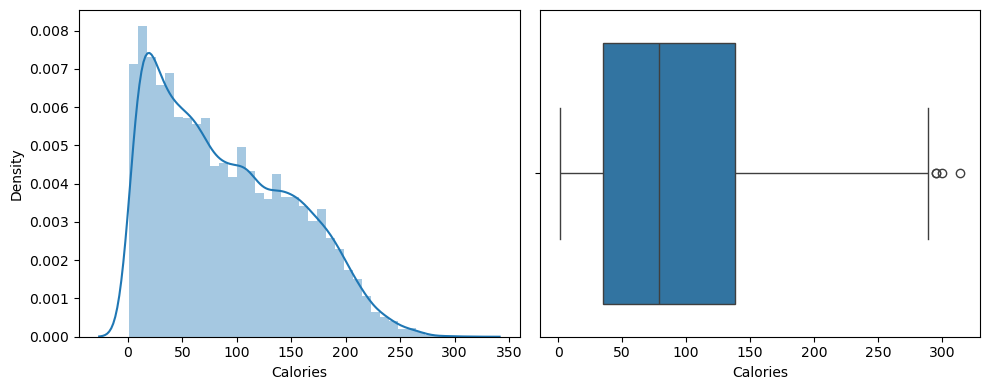

In [23]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.distplot(df['Calories'])
plt.subplot(1, 2, 2)
sns.boxplot(df['Calories'], orient='h')
plt.tight_layout()

#### Float Distribution

In [48]:
float_cols = df.select_dtypes(np.float_).columns.to_list()

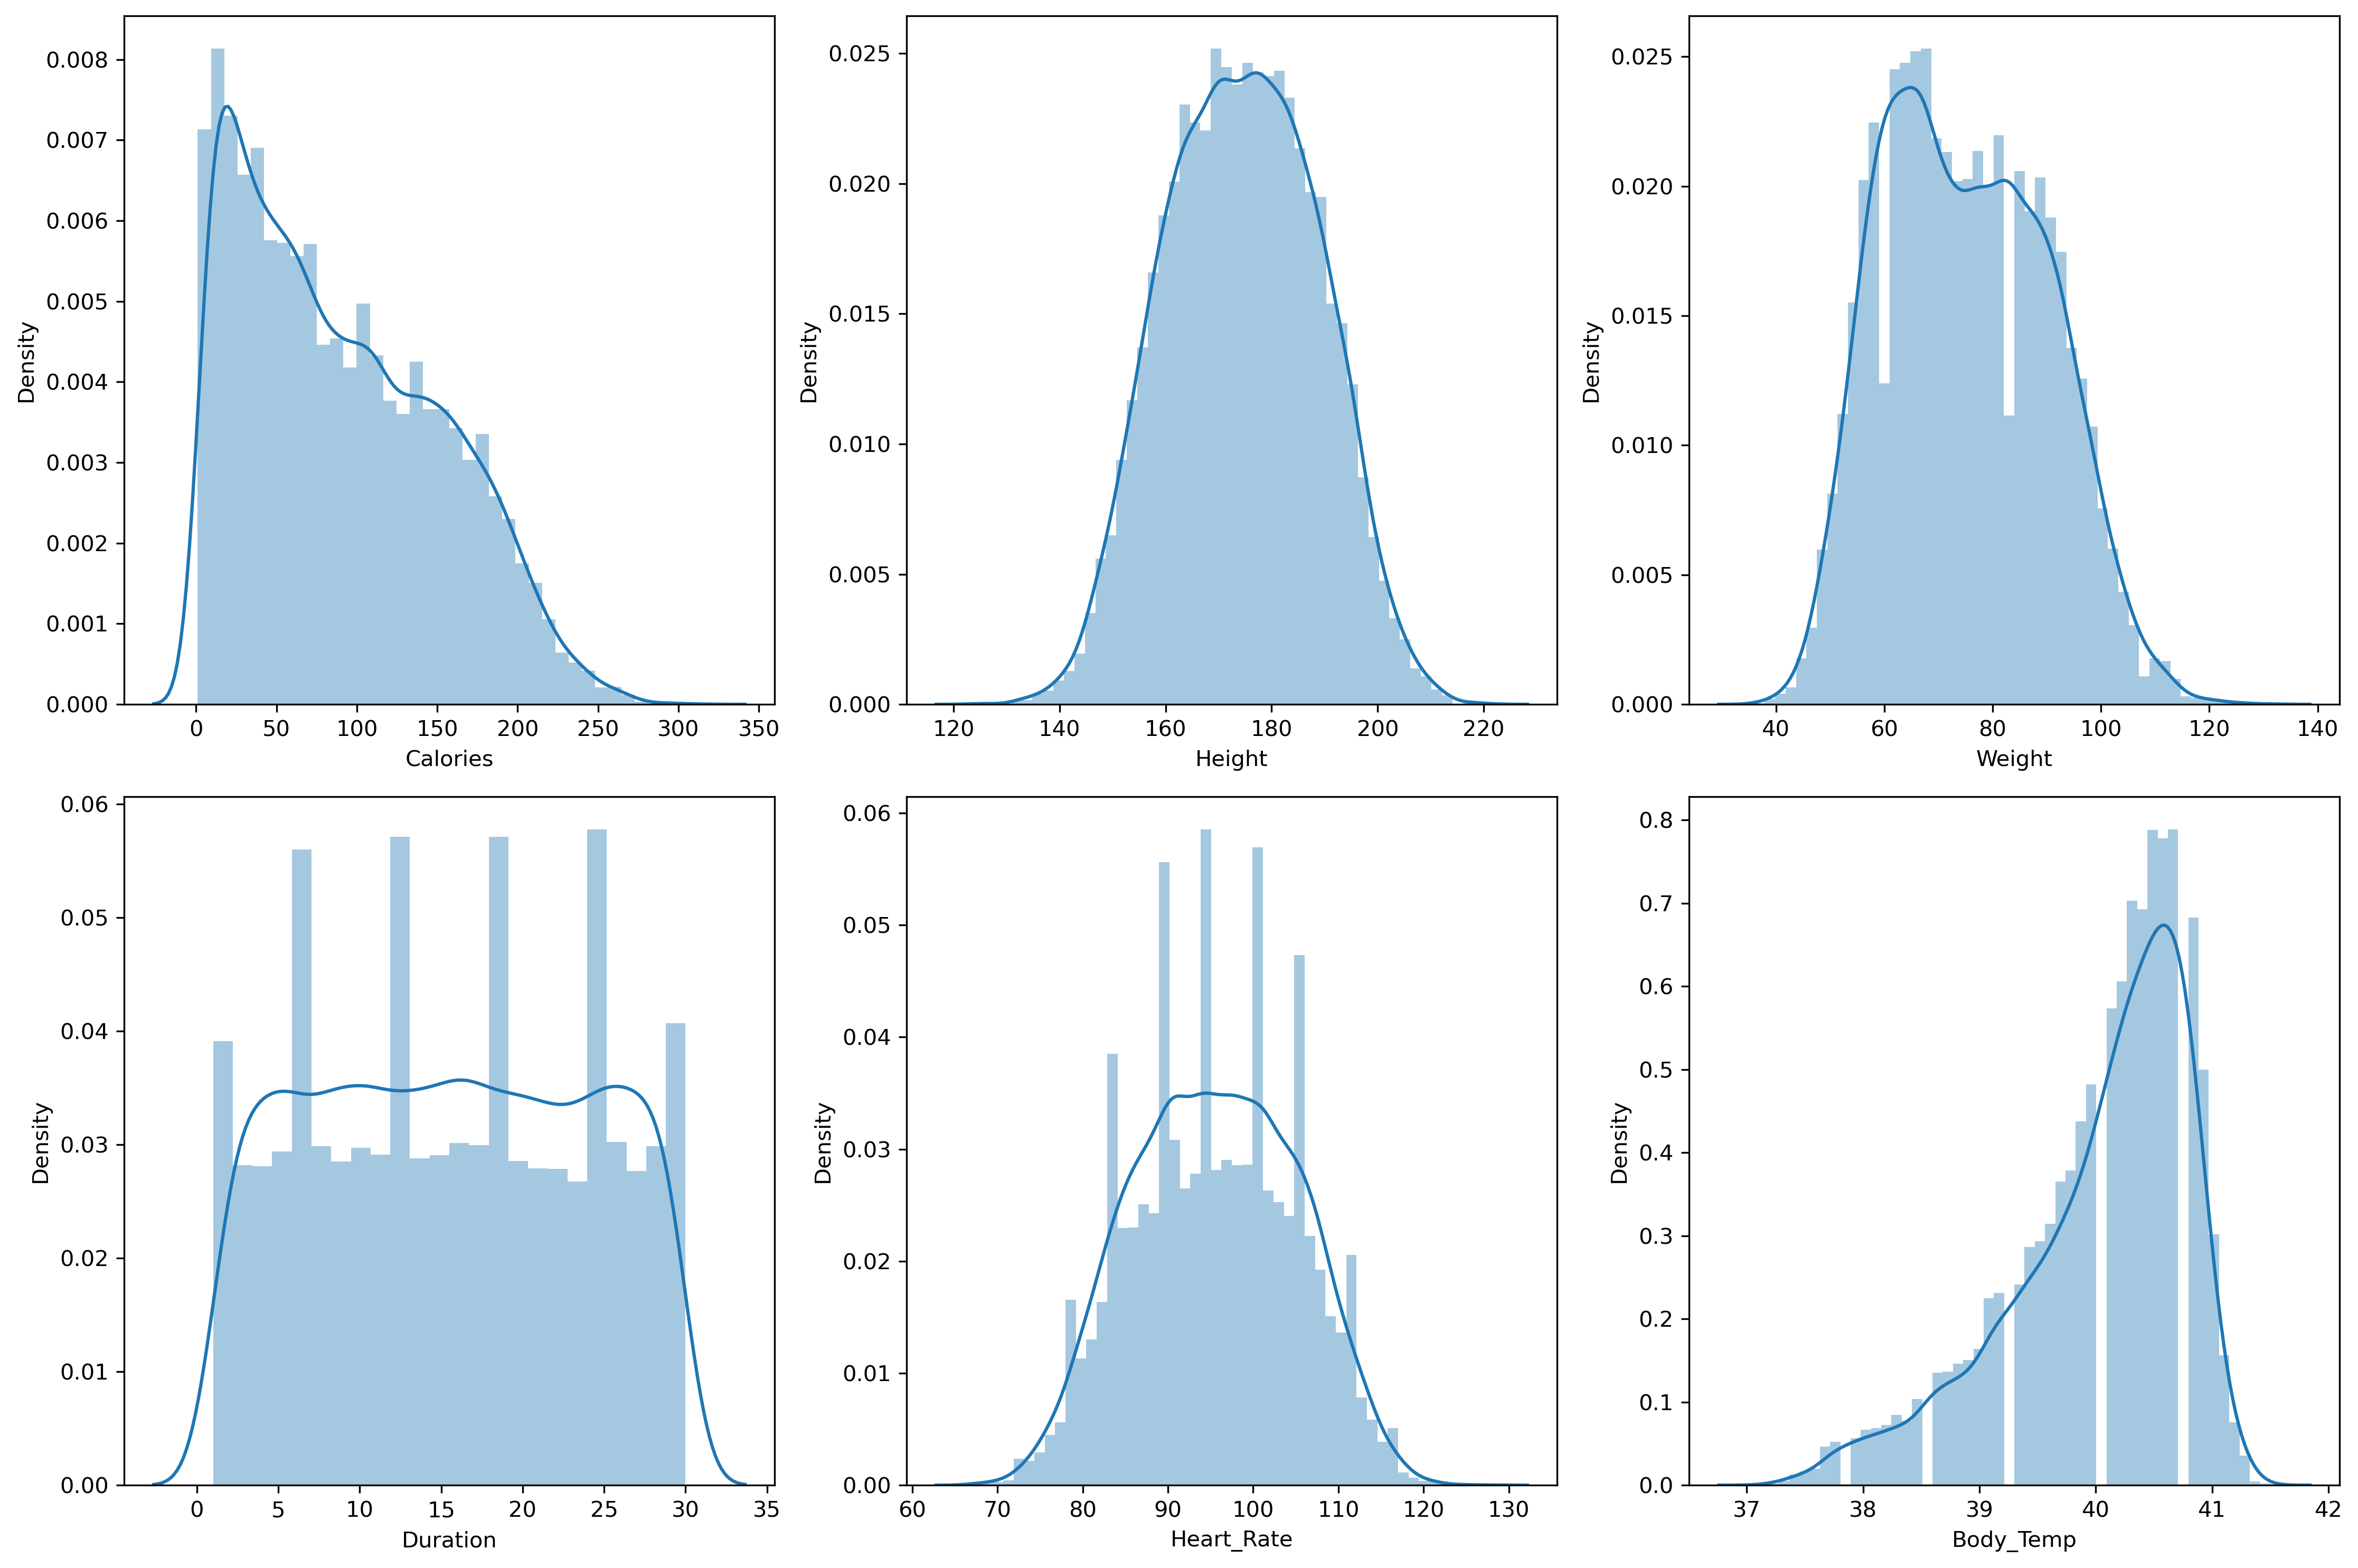

In [51]:
plt.figure(figsize=(15, 10), dpi=300)
for i, col in enumerate(float_cols):
    plt.subplot(2, 3, i+1)
    sns.distplot(df[col])
plt.tight_layout()

#### Number Distribution

In [37]:
num_cols = df.select_dtypes(np.number).columns.to_list()
num_cols.remove('Calories')
num_cols.remove('User_ID')

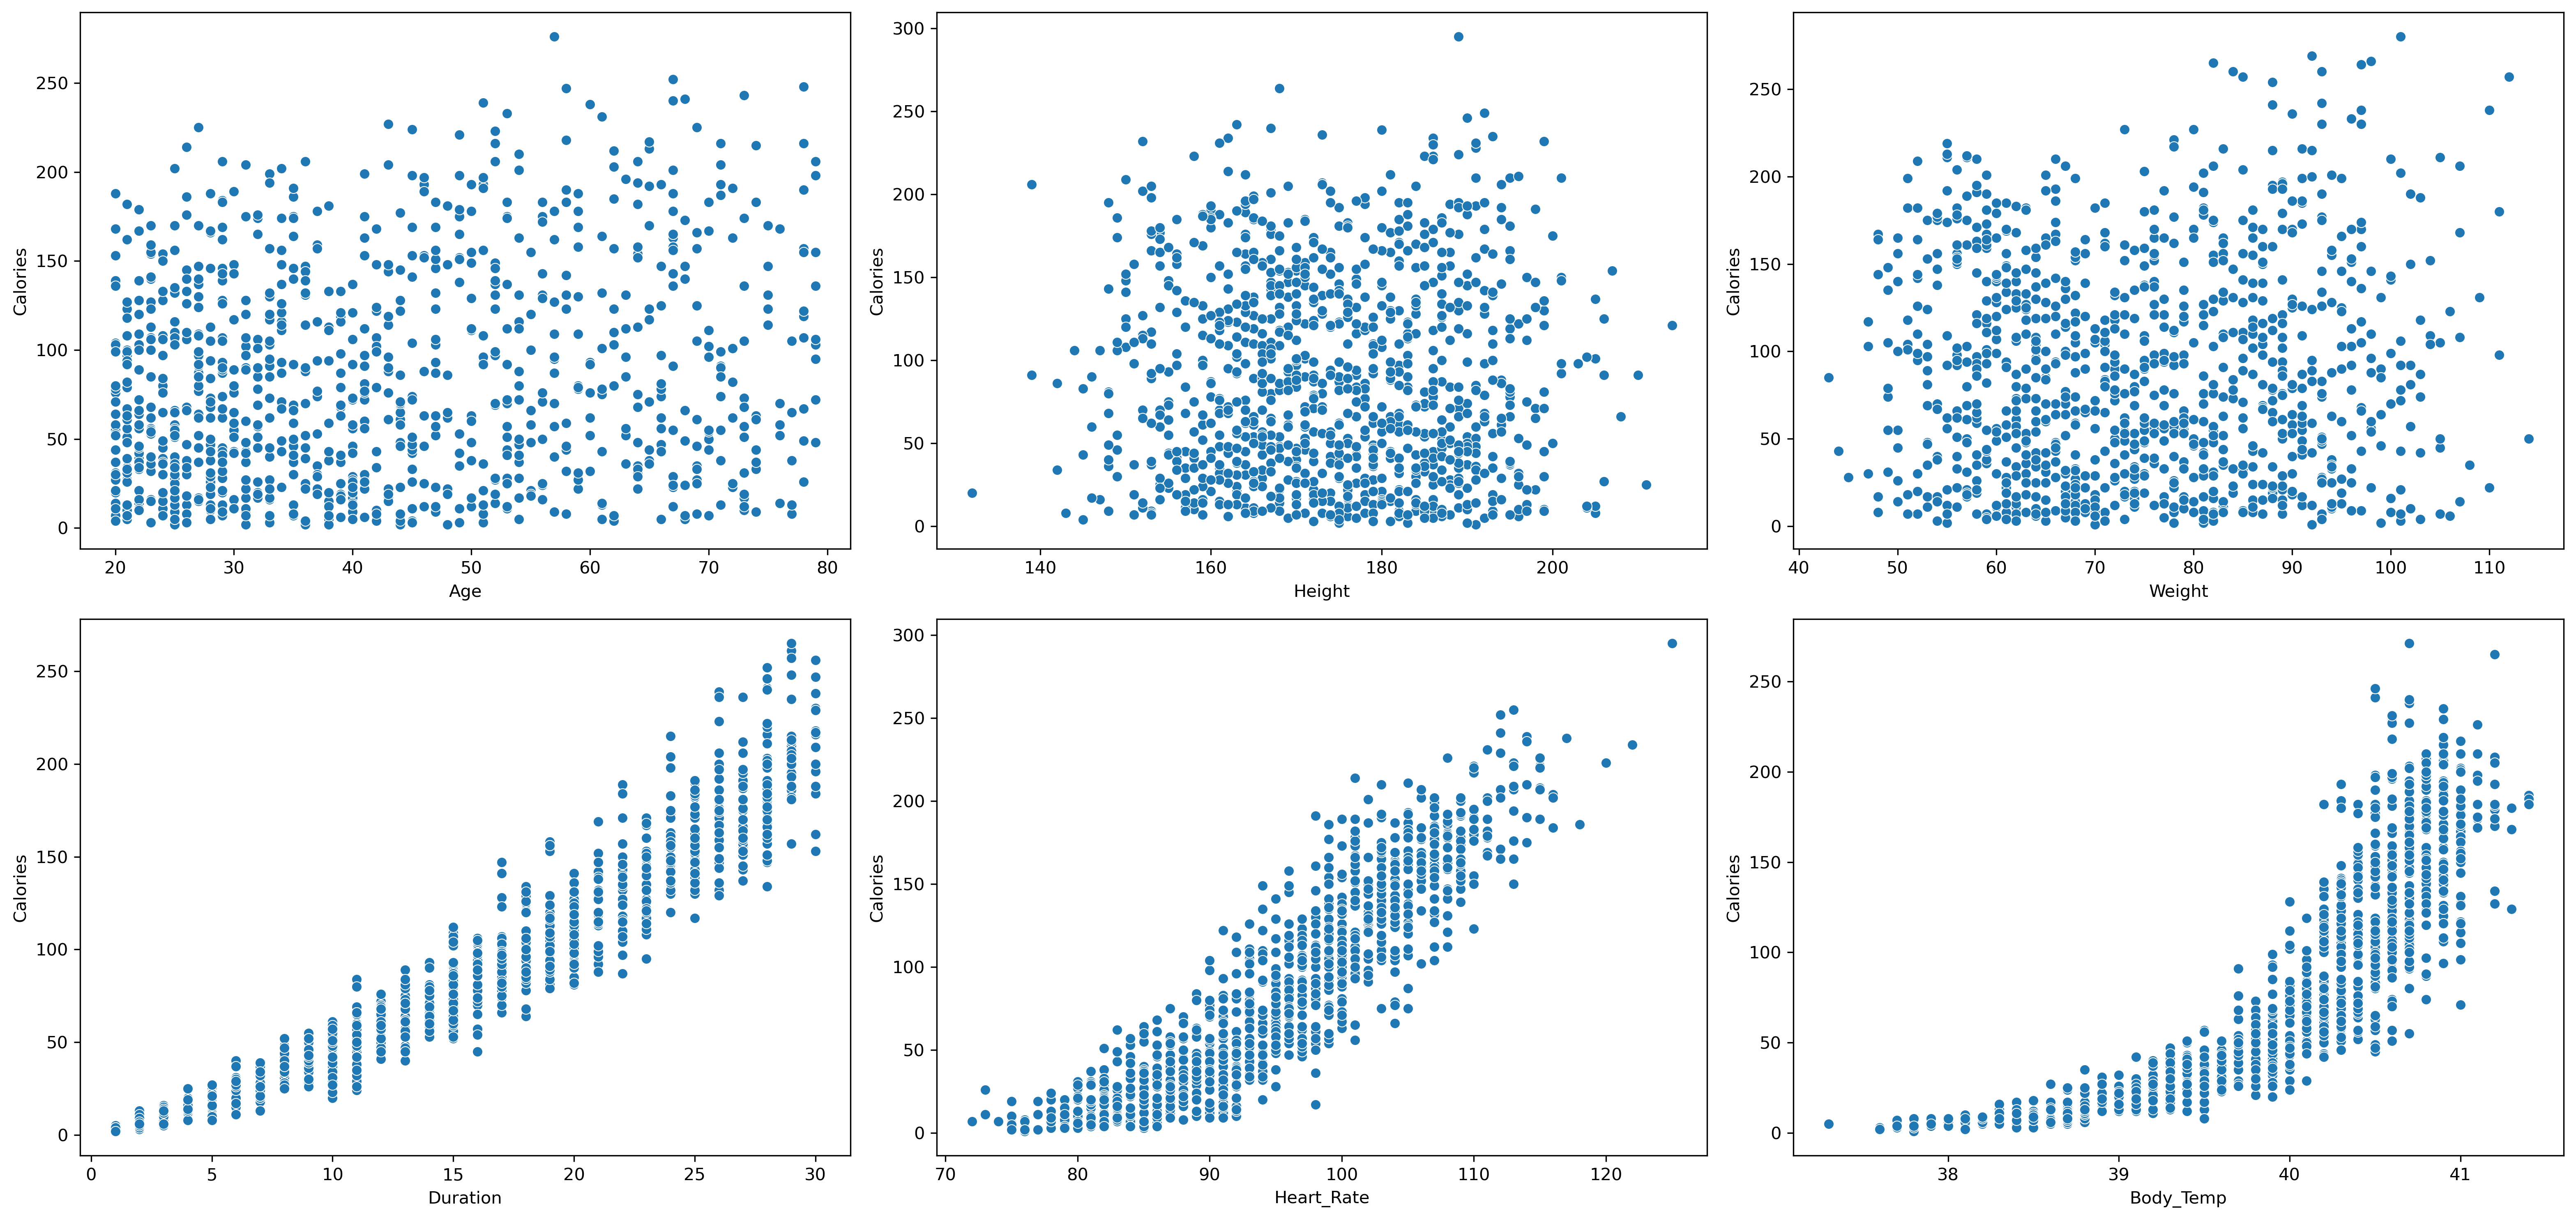

In [47]:
plt.figure(figsize=(21, 10), dpi=300)
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i+1)
    sns.scatterplot(x=col, y='Calories', data=df.sample(1000))
plt.tight_layout()

#### Other Distribution

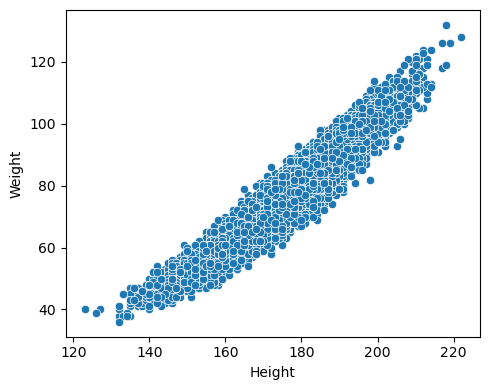

In [28]:
plt.figure(figsize=(5, 4))
sns.scatterplot(x='Height', y='Weight', data=df)
plt.tight_layout()

### Step 4: Feature Engineering

#### Label Encoding

In [52]:
obj_cols = df.select_dtypes(np.object_).columns.to_list()

In [54]:
for col in obj_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

#### Heat Map

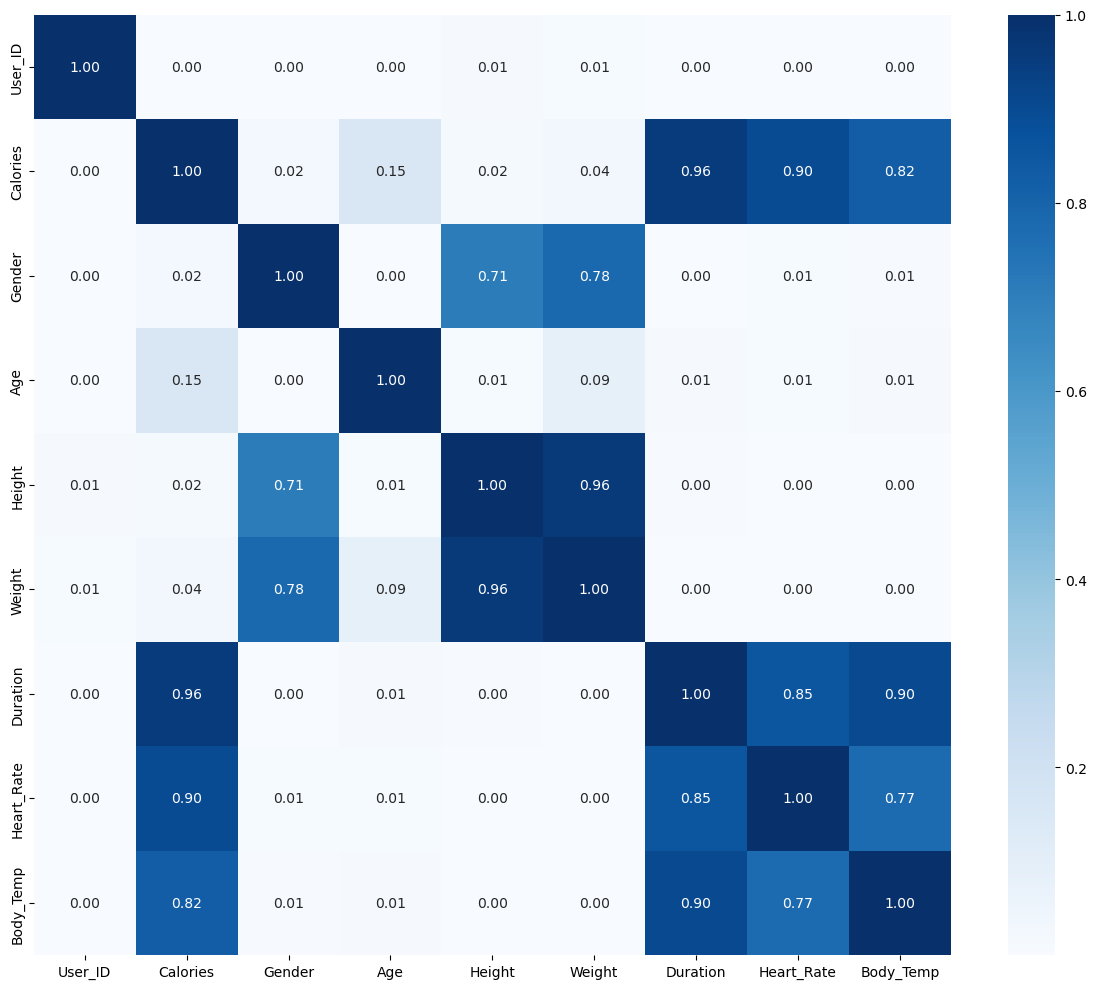

In [55]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    df.corr().abs(),
    fmt='.2f',
    annot=True,
    cmap=plt.cm.Blues
)
plt.tight_layout()

### Step 5: Preparing Data

#### Select Features

In [61]:
features = df.drop(['User_ID', 'Calories'], axis=1)
target = df['Calories']

In [63]:
selector = SmartCorrelatedSelection(threshold=0.9, selection_method='corr_with_target')

In [64]:
features = selector.fit_transform(features, target)

#### Split Data

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

#### Balance Data

In [67]:
ros = RandomOverSampler()

In [68]:
X_train, y_train = ros.fit_resample(X_train, y_train)

#### Normalization

In [69]:
scaler = StandardScaler()

In [70]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Step 6: Model Development

In [72]:
models = [
    LinearRegression(),
    XGBRegressor(),
    Lasso(),
    RandomForestRegressor(),
    Ridge()
]

In [74]:
for model in models:
    scores = cross_val_score(
        model,
        X_train, 
        y_train,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        error_score='raise'
    )
    print(f'Model: {model.__class__.__name__}')
    print(f'Accuracy Scores: {[round(score, 2) for score in scores]}')
    print(f'Accuracy Score: {round(scores.mean(), 2)}')

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f'Validation Error: {round(metrics.mean_absolute_error(y_test, y_pred), 2)}')
    print('-' * 20)

Model: LinearRegression
Accuracy Scores: [-348.93, -579.98, -355.81, -105.93, -1840.68]
Accuracy Score: -646.27
Validation Error: 13.91
--------------------
Model: XGBRegressor
Accuracy Scores: [-2.87, -2.37, -3.77, -9.06, -3.62]
Accuracy Score: -4.34
Validation Error: 1.69
--------------------
Model: Lasso
Accuracy Scores: [-322.52, -511.98, -357.73, -100.53, -2184.9]
Accuracy Score: -695.53
Validation Error: 13.49
--------------------
Model: RandomForestRegressor
Accuracy Scores: [-1.84, -1.77, -1.34, -2.38, -25.19]
Accuracy Score: -6.5
Validation Error: 1.84
--------------------
Model: Ridge
Accuracy Scores: [-348.91, -579.9, -355.82, -105.91, -1840.8]
Accuracy Score: -646.27
Validation Error: 13.91
--------------------


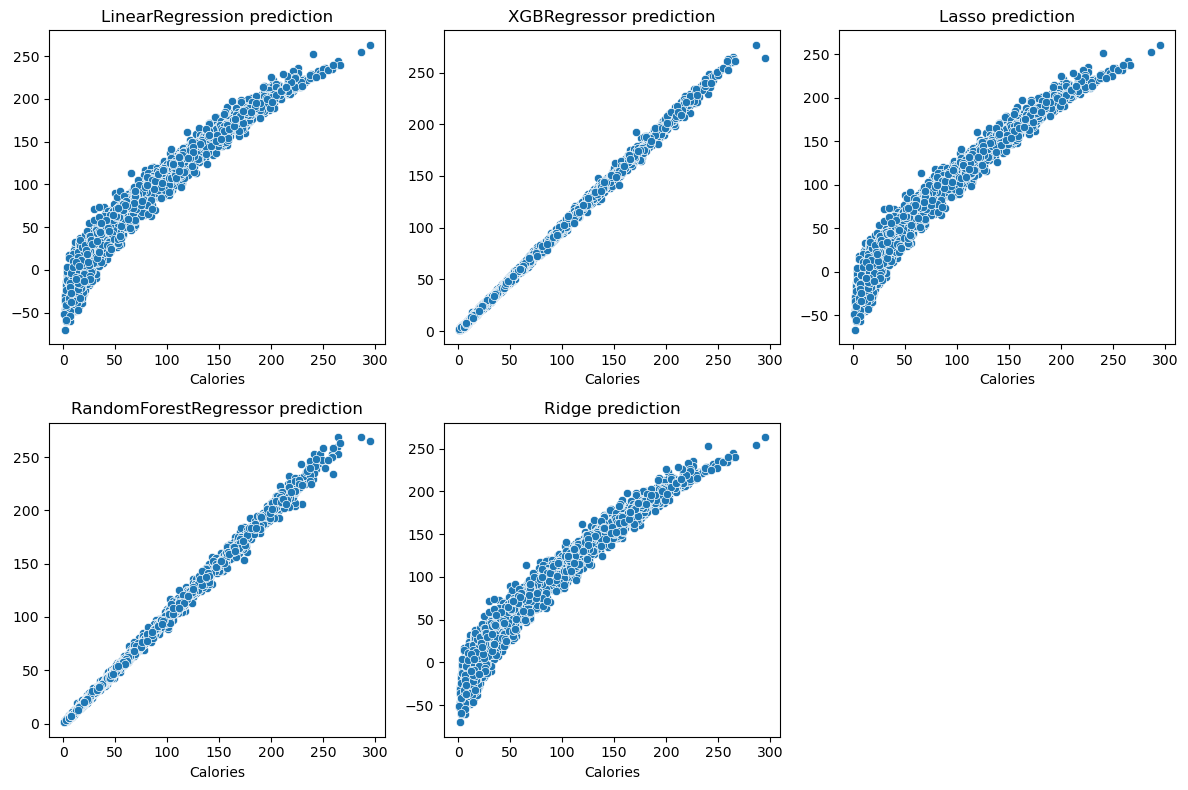

In [91]:
plt.figure(figsize=(12, 8))
for i, model in enumerate(models):
    plt.subplot(2, 3, i+1)
    y_pred = model.predict(X_test)
    sns.scatterplot(x=y_test, y=y_pred)
    plt.title(f'{model.__class__.__name__} prediction')
plt.tight_layout()